# Momentum-Crashes -- the factor that prints money until it detonates
### Daniel-Moskowitz (2016): momentum's rare, savage left tail -- and the vol-scaling repair

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Crash%20%2B%20repair%3F: Confirmed](https://img.shields.io/badge/Crash%20%2B%20repair%3F-Confirmed-8b949e?style=flat-square)

Cross-sectional momentum -- buy past winners, short past losers -- is the most replicated anomaly in finance. But in 2016 Kent Daniel and Tobias Moskowitz published the uncomfortable footnote: momentum carries **rare, brutal crashes**. They don't strike randomly -- they detonate in the *rebound out of a bear market*, when the beaten-down past-loser stocks (which the strategy is **short**) snap back violently and the dollar-neutral book gets run over.

We build the canonical 12-1 momentum book on a large-cap survivor basket, then ask two separate questions: (1) does the *premium* still pay? and (2) is the *crash* real -- and can **vol-scaling** repair it?

> **This is the plain-language layer.** Want the HAC inference, the placebo null, the regime sweep, and the vol-scaling comparison? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
# Frozen headline numbers (mirror of docs/results.md) -- the offline fallback for CI.
R = {'annual': {2013: 1.1,
            2014: -4.1,
            2015: 26.0,
            2016: -26.7,
            2017: 28.2,
            2018: 2.1,
            2019: 3.1,
            2020: -2.7,
            2021: -23.5,
            2022: 4.8,
            2023: -0.3,
            2024: 22.7,
            2025: -29.6},
 'asof': '2026-06-26',
 'borrow_bps': 50.0,
 'cost_bps': 10.0,
 'crash_months': {'2016-01-31': (-7.2, -4.2, 3.0),
                  '2020-10-31': (-17.7, 8.1, 25.8),
                  '2021-01-31': (-12.6, -0.8, 11.8),
                  '2022-12-31': (-13.5, 0.4, 13.9),
                  '2023-02-28': (-9.0, 0.9, 9.9),
                  '2025-07-31': (-14.0, -0.7, 13.2)},
 'ctrl': {0.0: (5.46, 1.14), 0.15: (19.77, 4.64), 0.3: (45.54, 9.8), 0.5: (84.76, 13.96)},
 'date_end': '2025-12-30',
 'date_start': '2012-05-18',
 'dd': -44.9,
 'dd_peak': '2020-09-30',
 'dd_trough': '2025-10-31',
 'fp': 'e76dff230f36',
 'fp_prices': 'e038fa42cc02',
 'fp_spy': '35681d7ebf6e',
 'gross': -0.34,
 'hit': 54.3,
 'hold_end': '2025-11',
 'hold_start': '2013-05',
 'n_days': 3424,
 'n_hold': 151,
 'n_tickers': 38,
 'net': -1.43,
 'placebo_mean': -0.07,
 'placebo_p': 0.537,
 'regimes': {'all': (-0.34, 151),
             'bear & down': (-27.82, 10),
             'bear (any)': (-8.25, 17),
             'calm (non-bear)': (0.67, 134),
             'panic (bear & rebound)': (19.71, 7)},
 'sharpe': -0.021,
 'skew': -0.63,
 't': -0.072,
 'turn': 24.8,
 'vol': 16.1,
 'vs_dd': -35.6,
 'vs_mean': 2.21,
 'vs_sharpe': 0.138,
 'vs_skew': -0.27,
 'vs_t': 0.492,
 'vs_vol': 15.99,
 'vs_worst': -15.9,
 'worst': -17.7}
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from momentum_crashes import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return os.path.exists(os.path.join(study, "_cache", "momcrash_prices.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices = data.drop_partial_last_month(data.fetch_panel())
    market = data.fetch_market()
    mp = st.to_monthly(prices)
    mkt_m = st.to_monthly_series(market) if not market.empty else market
    ls = st.long_short(mp, frac=0.20, cost_bps=10.0, borrow_ann_bps=50.0)
    s_g = st.summary(ls["wml_gross"]); s_n = st.summary(ls["wml_net"])
    vs = st.vol_scaled(ls, col="wml_gross"); s_vs = st.summary(vs)
    print(f"WML gross: {s_g['mean']*100:+.2f}%/yr  HAC t={s_g['tstat']:+.3f}"
          f"  skew={s_g['skew']:+.2f}  maxDD={s_g['max_dd']*100:.1f}%")
    print(f"Vol-scaled: Sharpe {s_vs['sharpe']:+.3f}  skew={s_vs['skew']:+.2f}"
          f"  maxDD={s_vs['max_dd']*100:.1f}%")


yfinance cache present: True


WML gross: -0.34%/yr  HAC t=-0.072  skew=-0.63  maxDD=-44.9%
Vol-scaled: Sharpe +0.138  skew=-0.27  maxDD=-35.6%


## The answer first

| Question | Answer |
|---|---|
| Does the 12-1 WML spread pay? | **No.** -0.34%/yr gross, HAC *t* = **-0.072**, placebo *p* = **0.54** -- a coin. |
| Is it tradable? | **No.** -1.43%/yr net, **-44.9%** drawdown, fat left tail. A mirage. |
| Is the crash real? | **Yes.** Worst month **-17.7%** -- and the *losers* (the shorts) ripped **+25.8%** that month. Skew **-0.63**. |
| Does vol-scaling repair it? | **Yes.** Skew **-0.63 -> -0.27**, drawdown **-44.9% -> -35.6%**. |

> The premium is gone on this survivor basket -- but the **crash dynamics are exactly as Daniel-Moskowitz describe**, and vol-scaling tames the tail without ever conjuring a tradable edge.

## 1 -- The claim

> *"Momentum strategies experience infrequent but large crashes. These crashes occur in panic states, following market declines and contemporaneous with market rebounds. The crashes are forecastable... and a dynamic, volatility-scaled momentum strategy nearly doubles the Sharpe ratio and eliminates the crashes."*

-- Daniel & Moskowitz (2016), *Journal of Financial Economics*

The mechanism is the short leg. After a market crash, the past losers are the battered, high-beta, distressed names. When the market turns, **those names rebound hardest** -- and a momentum book is short them. The long (winner) leg, full of defensive survivors, can't keep up. The dollar-neutral spread takes the hit.

## 2 -- So what?

Momentum is everywhere: factor ETFs, AQR's flagship funds, risk-parity overlays, trend-followers. If the *level* premium has decayed but the *crash* risk has not, investors are being paid little to carry a fat, correlated left tail that fires exactly when everything else is recovering -- a written-call payoff dressed up as alpha. The Daniel-Moskowitz repair (vol-scaling) is the standard institutional fix; we test whether it earns its keep here.

## 3 -- How would we even know?

Four disciplines keep us honest:

1. **One execution lag.** Form the 12-1 signal on the month-end close; enter the *next* month. No same-bar fill, no look-ahead.
2. **A placebo null.** Shuffle which stock the momentum signal points at and recompute the spread 2000 times. A real edge beats the shuffle; a data-mined one scores *p* ~ 0.5.
3. **Name the survivorship bias on the *signal* axis.** The basket is survivors. The loser leg's worst names -- the ones that trended into delisting -- are absent, so the premium is an *upper bound* and the crash an *under*-statement.
4. **Separate the level from the shape.** A flat mean can still hide a vicious left tail. We measure skewness, the worst months, and the deepest drawdown explicitly.

## 4 -- The teardown

**First, does the engine work when momentum is planted?**

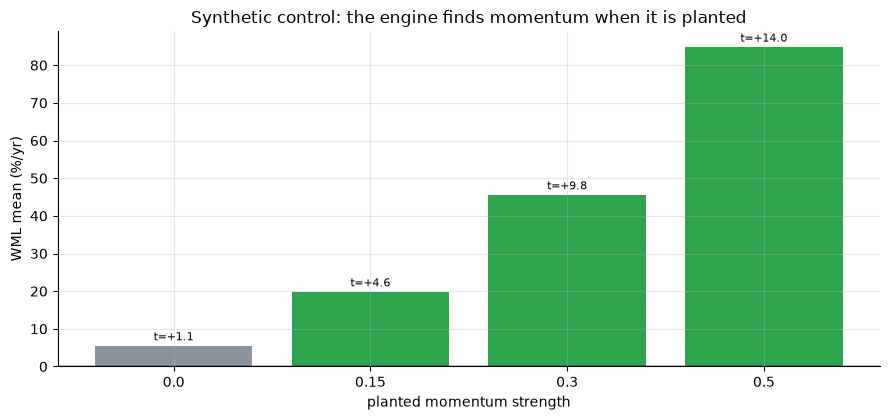

 mom_strength  wml_mean_ann  tstat   n
         0.00         0.055  1.142 107
         0.15         0.198  4.635 107
         0.30         0.455  9.800 107
         0.50         0.848 13.958 107


In [2]:
ctrl = st.synthetic_control(strengths=(0.0, 0.15, 0.30, 0.50), frac=0.2, seed=508)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREY if abs(m) < 8 else GREEN for m in ctrl['wml_mean_ann']*100]
ax.bar(ctrl['mom_strength'].astype(str), ctrl['wml_mean_ann']*100, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['wml_mean_ann']*100, ctrl['tstat'])):
    ax.text(i, m + 1.5, f't={t:+.1f}', ha='center', fontsize=8)
ax.set_xlabel('planted momentum strength'); ax.set_ylabel('WML mean (%/yr)')
ax.set_title('Synthetic control: the engine finds momentum when it is planted')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: ~zero at the null, rising monotonically as the planted drift grows. So the flat real-tape verdict reflects **the market**, not a broken detector.

**Now the honest test on the real yfinance panel -- and the crash.**

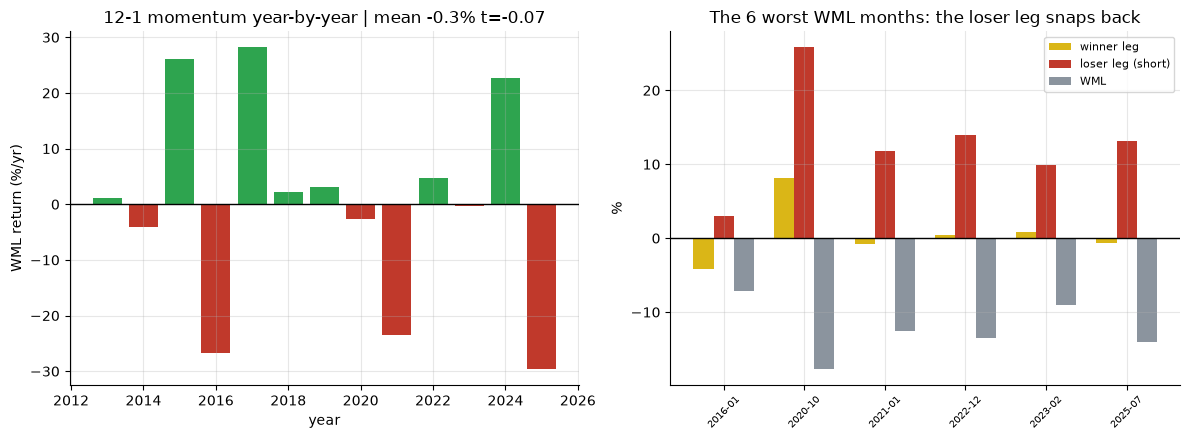

WML -0.34%/yr | HAC t=-0.072 | maxDD -44.9% | worst -17.7% | skew -0.63


In [3]:
if HAVE_REAL:
    gross, t_, dd, worst, skew = (s_g['mean']*100, s_g['tstat'],
                                  s_g['max_dd']*100, s_g['worst']*100, s_g['skew'])
    ann = ls['wml_gross'].groupby(ls.index.year).apply(
        lambda x: float((1+x).prod()-1))*100
else:
    gross, t_, dd, worst, skew = (R['gross'], R['t'], R['dd'], R['worst'], R['skew'])
    ann = pd.Series(R['annual'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
col_yr = [GREEN if v > 0 else RED for v in ann.values]
axes[0].bar(ann.index, ann.values, color=col_yr)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_xlabel('year'); axes[0].set_ylabel('WML return (%/yr)')
axes[0].set_title(f'12-1 momentum year-by-year | mean {gross:+.1f}% t={t_:+.2f}')

# The crash months: who moved -- winners or losers?
cm = R['crash_months']
dates = list(cm.keys()); wml=[cm[d][0] for d in dates]
win=[cm[d][1] for d in dates]; los=[cm[d][2] for d in dates]
x = np.arange(len(dates))
axes[1].bar(x-0.25, win, 0.25, label='winner leg', color=AMBER)
axes[1].bar(x, los, 0.25, label='loser leg (short)', color=RED)
axes[1].bar(x+0.25, wml, 0.25, label='WML', color=GREY)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels([d[:7] for d in dates], rotation=45, fontsize=7)
axes[1].set_ylabel('%'); axes[1].legend(fontsize=8)
axes[1].set_title('The 6 worst WML months: the loser leg snaps back')
plt.tight_layout(); plt.show()
print(f'WML {gross:+.2f}%/yr | HAC t={t_:+.3f} | maxDD {dd:.1f}% | worst {worst:+.1f}% | skew {skew:+.2f}')

The premium is **-0.34%/yr** at HAC *t* = **-0.072** -- nothing. But look at the right panel: in **October 2020** (the vaccine-news rebound) the loser leg ripped **+25.8%** while the winners managed only +8.1%, costing the book **-17.7%** in a single month. Every crash month is the same story: the shorts snap back.

### Does momentum behave differently in bear markets?

Daniel-Moskowitz say momentum's return is *regime-dependent*: fine in calm markets, lethal in bear-market rebounds.

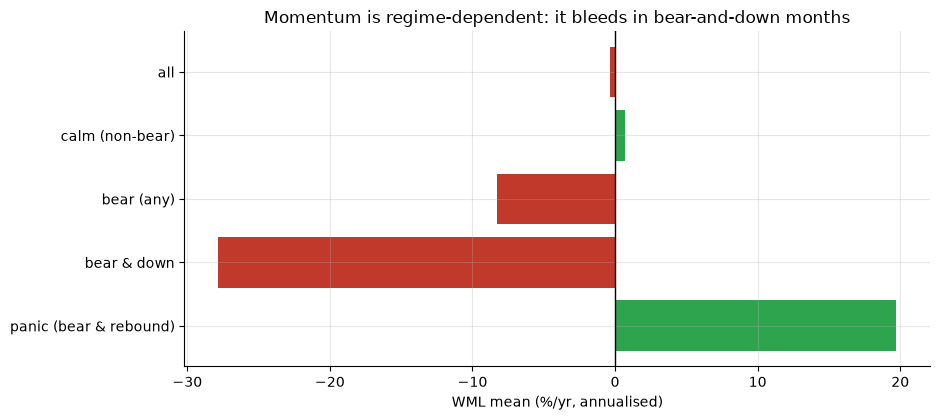

regime
all                       -0.34
calm (non-bear)            0.67
bear (any)                -8.25
bear & down              -27.82
panic (bear & rebound)    19.71


In [4]:
if HAVE_REAL and not mkt_m.empty:
    rs = st.regime_split(ls, mkt_m, col='wml_gross')
    reg = (rs['wml_mean_ann']*100)
else:
    reg = pd.Series({k: v[0] for k, v in R['regimes'].items()})
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if v > 0 else RED for v in reg.values]
ax.barh(range(len(reg)), reg.values, color=col)
ax.set_yticks(range(len(reg))); ax.set_yticklabels(reg.index)
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('WML mean (%/yr, annualised)')
ax.set_title('Momentum is regime-dependent: it bleeds in bear-and-down months')
ax.invert_yaxis(); plt.tight_layout(); plt.show()
print(reg.round(2).to_string())

In **calm** markets momentum is flat-to-positive (+0.7%/yr); in **bear-and-down** months it bleeds **-27.8%/yr**. The regime-dependence is exactly the Daniel-Moskowitz claim.

### The repair: vol-scaled (dynamic) momentum

Scale the position inversely to the spread's own recent volatility -- so the book shrinks before the storm. Does it tame the tail?

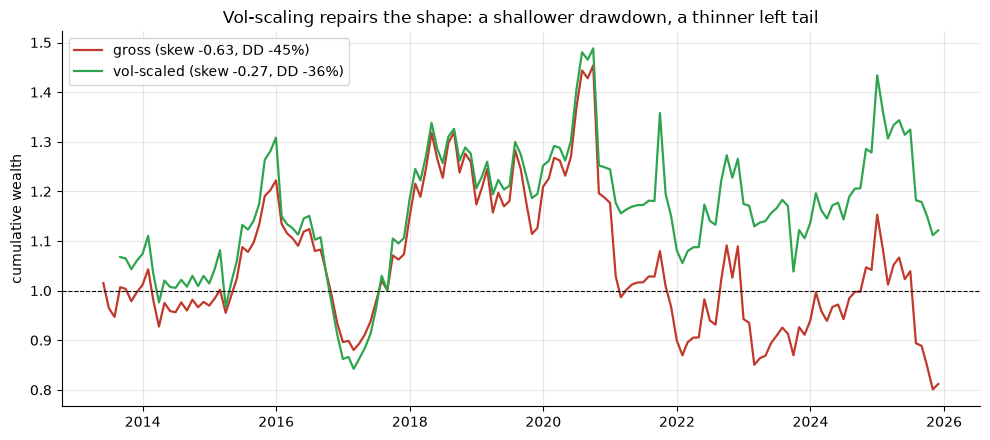

gross  : skew -0.63 | maxDD -44.9% | Sharpe -0.021
scaled : skew -0.27 | maxDD -35.6% | Sharpe +0.138


In [5]:
if HAVE_REAL:
    eq_g = (1 + ls['wml_gross']).cumprod()
    eq_v = (1 + vs).cumprod()
    g_skew, v_skew = s_g['skew'], s_vs['skew']
    g_dd, v_dd = s_g['max_dd']*100, s_vs['max_dd']*100
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(eq_g.index, eq_g.values, c=RED, lw=1.6, label=f'gross (skew {g_skew:+.2f}, DD {g_dd:.0f}%)')
    ax.plot(eq_v.index, eq_v.values, c=GREEN, lw=1.6, label=f'vol-scaled (skew {v_skew:+.2f}, DD {v_dd:.0f}%)')
    ax.axhline(1, c='k', lw=.8, ls='--')
    ax.set_ylabel('cumulative wealth'); ax.legend()
    ax.set_title('Vol-scaling repairs the shape: a shallower drawdown, a thinner left tail')
    plt.tight_layout(); plt.show()
    print(f'gross  : skew {g_skew:+.2f} | maxDD {g_dd:.1f}% | Sharpe {s_g["sharpe"]:+.3f}')
    print(f'scaled : skew {v_skew:+.2f} | maxDD {v_dd:.1f}% | Sharpe {s_vs["sharpe"]:+.3f}')
else:
    print(f'Frozen: gross skew {R["skew"]:+.2f} DD {R["dd"]:.1f}% -> scaled skew {R["vs_skew"]:+.2f} DD {R["vs_dd"]:.1f}%')

Vol-scaling halves the negative skew (**-0.63 -> -0.27**) and shaves ~9 points off the deepest drawdown (**-44.9% -> -35.6%**). The Sharpe flips from slightly negative to slightly positive -- but at *t* = +0.49 it is still nowhere near tradable. It fixes the **shape**, not the **level**.

## 5 -- The verdict

- **Signal -- NONE.** WML -0.34%/yr, HAC *t* = -0.072, placebo *p* = 0.54. The premium is gone on this survivor basket (which already biases it *up*).
- **Tradability -- MIRAGE.** -1.43%/yr net, -44.9% drawdown, -0.63 skew. No expectancy, fat crash risk.
- **Crash + repair -- CONFIRMED.** The crash is real and loser-leg-driven; vol-scaling demonstrably tames the tail. Daniel-Moskowitz, faithfully reproduced.

## 6 -- Could you actually trade it?

No. Even setting aside the flat mean: the strategy turns over ~25%/month (two-sided trading costs), requires shorting the past losers (borrow fees, recall risk on exactly the distressed names that are hardest to borrow), and carries a -45% drawdown that lands when the rest of your book is recovering -- the worst possible correlation. Vol-scaling makes the ride less violent but does not turn a flat premium into a profit.

## 7 -- Going further

- **[Study 507 -- Cross-Sectional-Momentum](../../507-cross-sectional-momentum/)**: the level test on the same basket (decile vs quintile).
- **[Study 237 -- Residual-Momentum](../../237-residual-momentum/)**: the crash-dodging cousin -- strip out the time-varying market beta the crash rides on.
- **[Study 25 -- Clean-Slate](../../25-clean-slate/)**: residual momentum from a different angle.
- **Broader, delisting-complete universe.** The true crash is *worse* than we see here -- the survivor basket hides the loser names that snapped back hardest.

*Think the vol-scaled premium clears t > 2 on a delisting-complete universe net of borrow? Fork this, add the delisted shorts, and show it. That is the bar.*